<p align="left">
  <a href="https://colab.research.google.com/github/wgomezf/analisis_datos/blob/main/03_Redes_neuronales_artificiales/mlp_full.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" width="200">
  </a>
</p>

In [ ]:
#########################################################
# Autor: Wilfrido Gómez Flores (Cinvestav)              #
# E-mail: wgomez@cinvestav.mx                           #
# Curso:  Análisis de datos                             #
# Tópico: MLP full batch                                #
#########################################################

Carga bibliotecas necesarias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Carga el conjunto de datos Iris con 3 clases, 150 muestras y 4 variables

In [ ]:
iris = load_iris()
df = pd.DataFrame(data=iris.data)
X = df.to_numpy() # Características
df = pd.DataFrame(data=iris.target)
Y = df.to_numpy() # Etiquetas de clase: 1,2 3
d = X.shape[1] # Número de variables
c = np.unique(Y).size # Número de clases

Divide el conjunto de datos en 80\% para entrenamiento y 20\% para prueba

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

Normaliza el conjunto de datos con z-score:  $z = \frac{x-\mu}{\sigma}$

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Normaliza el conjunto de entrenamiento
X_test = scaler.transform(X_test) # Normaliza el conjunto de prueba usando los estadísticos del conjunto de entrenamiento

Entrenamiento MLP con backpropagation

In [ ]:
def mlp_train(X, Y, h, eta, l, epochMax):
    Y = Y.flatten()
    c = len(np.unique(Y))
    n, d = X.shape
    tk = (Y[:, None] == np.arange(c)).astype(float)  # One-hot encoding
    ones = np.ones((n, 1))
    X = np.hstack((ones, X))                                # Add dummy inputs for biases calculation
    # Functions
    sg = lambda x: 1 / (1 + np.exp(-x))                                     # Sigmoid activation function
    sm = lambda x: np.exp(x) / np.sum(np.exp(x), axis=1, keepdims=True)     # Softmax function
    ce = lambda t, z: -np.sum(t * np.log(z + np.finfo(float).eps), axis=1)  # Cross-entropy loss function
    # Weights initialization
    rd = lambda a, b, s, t: a + (b - a) * np.random.rand(s, t)  # LeCun initialization
    Wji = rd(-np.sqrt(3/d), np.sqrt(3/d), h, d + 1)             # Input-hidden layer weights
    Wkj = rd(-np.sqrt(3/h), np.sqrt(3/h), c, h + 1)             # Hidden-output layer weights
    # Training loop
    Jn = np.zeros(epochMax)  # Save loss function
    for t in range(epochMax):
        # Shuffle data every epoch
        id = np.random.permutation(n)
        X = X[id, :]
        tk = tk[id, :]
        # Feedforward
        yj = sg(X @ Wji.T)                          # Hidden layer response
        yj = np.hstack((ones, yj))                  # Add dummy inputs
        zk = sm(yj @ Wkj.T)                         # Output layer response
        L2 = l * (np.sum(Wji**2) + np.sum(Wkj**2))  # Regularization term
        Jn[t] = np.mean(ce(tk, zk)) + L2            # Cross-entropy loss (regularized)
        # Backpropagation
        dk = zk - tk                      # Delta k
        Dwkj = dk.T @ yj                  # Delta rule hidden-output
        dj = (dk @ Wkj) * (yj * (1 - yj)) # Delta j
        Dwji = dj[:, 1:h + 1].T @ X       # Delta rule input-hidden
        # Weights update (regularized)
        Wji = (1 - eta * l) * Wji - eta * Dwji  # Input-hidden
        Wkj = (1 - eta * l) * Wkj - eta * Dwkj  # Hidden-output
    return Wji, Wkj, Jn

Predice con MLP

In [ ]:
def mlp_predict(X, Wji, Wkj):
    sg = lambda x: 1 / (1 + np.exp(-x))                                 # Sigmoid activation function
    sm = lambda x: np.exp(x) / np.sum(np.exp(x), axis=1, keepdims=True) # Softmax function
    unos = np.ones((X.shape[0], 1))                                     # Ones vector
    X = np.hstack((unos, X))                                            # Add dummy inputs
    yj = sg(X @ Wji.T)                                                  # Hidden layer response
    yj = np.hstack((unos, yj))                                          # Add dummy inputs
    zk = sm(yj @ Wkj.T)                                                 # Output layer response
    ypp = np.argmax(zk, axis=1)                                         # Classification by maximum probability
    ypp = ypp.reshape(-1, 1) # Asegurar vector columna
    return ypp, zk

Entrenamiento y clasificación

In [ ]:
h = 10 # Número de neuronas ocultas
epochMax = 5000 # Épocas de entrenamiento
eta = 1e-3  # Tasa de aprendizaje
lam = 1e-8  # factor de regularización
Wji, Wkj, Jn = mlp_train(X_train, Y_train, h, eta, lam, epochMax)  # Entrena MLP
Y_pred, _ = mlp_predict(X_test, Wji, Wkj) # Predice con MLP

Visualiza matriz de confusión y curva de aprendizaje

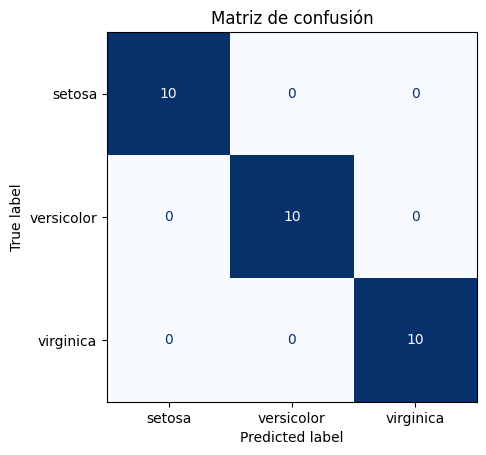

Exactitud: 1.000


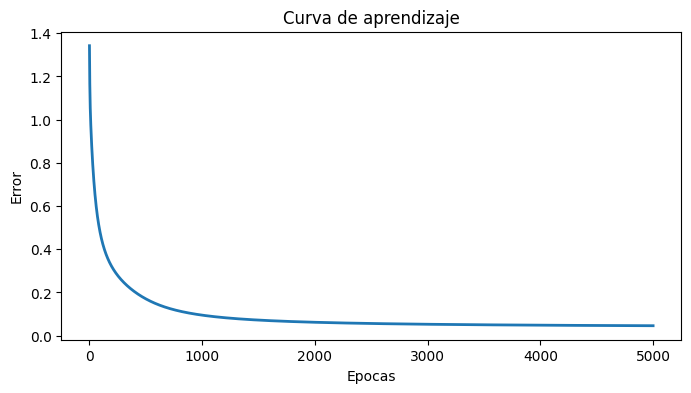

In [ ]:
cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(colorbar=False, cmap='Blues')
plt.title('Matriz de confusión')
plt.show()
ACC = np.mean(Y_pred == Y_test)
print(f"Exactitud: {ACC:.3f}")

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(Jn) + 1), Jn, linewidth=2)
plt.xlabel('Epocas')
plt.ylabel('Error')
plt.title('Curva de aprendizaje')
plt.show()